# Lesson Coverage

## Data Preparation

- [x] Duplicates handled
- [x] Missing Data checked / handled if necessary
- [x] Outliers inspected
- [x] Encoding
- [x] Scaling

## K-Nearest Neighbors

- [ ] KNN Regression
- [ ] KNN Classification
- [ ] n_neighbors
- [ ] weights
- [ ] p = 1 / Manhattan
- [ ] p = 2 / Euclidean

## Baselines

- [ ] DummyRegressor
- [ ] DummyClassifier

## Regression Metrics

- [ ] Residuals
- [ ] MSE
- [ ] RMSE
- [ ] MAE
- [ ] Max Error
- [ ] R?
- [ ] cross_validate with multiple metrics

## Classification Metrics

- [ ] Confusion Matrix
- [ ] TP
- [ ] TN
- [ ] FP
- [ ] FN
- [ ] Accuracy
- [ ] Precision
- [ ] Recall
- [ ] F1

## Threshold Evaluation

- [ ] LabelEncoder
- [ ] predict_proba
- [ ] cross_val_predict
- [ ] precision_recall_curve
- [ ] Precision?Recall plot
- [ ] Business Recall target
- [ ] Custom Threshold
- [ ] Precision / Recall comparison after threshold change

## ROC

- [ ] ROC Curve
- [ ] True Positive Rate
- [ ] False Positive Rate
- [ ] ROC-AUC

## Final Analysis

- [ ] Error Analysis
- [ ] Cohort Analysis
- [ ] Final metric interpretation

# 1. Project Goal

This project studies how different machine-learning evaluation metrics tell different stories about model performance using the **Medical Insurance Charges** dataset.

The project will explore two distinct machine-learning tasks:

### Task A ? Regression
Predict individual medical insurance `charges` based on patient attributes (age, sex, BMI, children, smoking status, and region).

### Task B ? Classification
Later in the project, we will create a classification target `price_range` with two categories:
- `cheap`
- `expensive`

We will evaluate classification models against various probability thresholds, trade-offs between precision and recall, and ROC-AUC.

> **Scope Notice for Step 1**: In this initial step, we focus exclusively on raw data auditing, quality checks, and outlier inspection. We do **not** create the `price_range` target yet, do **not** apply encodings or scalings, do **not** split into train/test, and do **not** train any models.

# 2. Load Data

We load the raw dataset from `data/insurance.csv` using `pandas` and inspect its basic dimensions and structure.

In [1]:
import pandas as pd

data = pd.read_csv("data/insurance.csv")

In [2]:
data.shape

(1338, 7)

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

The dataset loaded contains 1,338 rows and 7 columns, matching the expected schema:
- `age`: integer / numeric
- `sex`: string categorical (`female`, `male`)
- `bmi`: float continuous
- `children`: integer count
- `smoker`: string categorical (`yes`, `no`)
- `region`: string categorical (`northeast`, `southeast`, `southwest`, `northwest`)
- `charges`: float continuous (regression target)

# 3. Understand the Data

We now examine the data types, non-null counts, and summary statistics across all columns.

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Next, we inspect the frequency distributions of each categorical variable using `value_counts()`.

In [7]:
data["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [8]:
data["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [9]:
data["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

**Categorical Insights:**
- `sex`: Very evenly split between male (676) and female (662).
- `smoker`: Approximately 20.5% smokers (274) and 79.5% non-smokers (1,064). Smoking status may be strongly related to charges and will be examined empirically during modelling and error analysis.
- `region`: Evenly distributed across all 4 US regions (southeast has slightly more records at 364, while the others have 324?325).

# 4. Duplicates

We check for duplicate rows in the dataset using `duplicated()` and calculate the total count.

In [10]:
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [11]:
duplicate_count = data.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 1


In [12]:
if duplicate_count > 0:
    display(data[data.duplicated(keep=False)])
else:
    print("No duplicate rows found.")

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


Duplicate observations can distort model evaluation if the same observation appears in both training and test data.

Inspection reveals 1 duplicate pair (row 195 and row 581: a 19-year-old male, non-smoker, BMI 30.59, 0 children, northwest, charge 1639.5631).

In Step 1, we do **not** remove duplicates yet, preserving the raw dataset exactly as loaded for audit purposes.

# 5. Missing Data

We check for missing or null values in each feature and across the entire dataset.

In [13]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [14]:
total_missing = data.isnull().sum().sum()
print(f"Total missing values: {total_missing}")

Total missing values: 0


The dataset contains no missing values, so imputation is not required for this project.

# 6. Numerical / Categorical Features

We partition features by their data type into numerical and categorical subsets.

In [15]:
numerical_features = ["age", "bmi", "children", "charges"]
categorical_features = ["sex", "smoker", "region"]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'bmi', 'children', 'charges']
Categorical features: ['sex', 'smoker', 'region']


In [16]:
data[numerical_features].dtypes

age           int64
bmi         float64
children      int64
charges     float64
dtype: object

In [17]:
data[categorical_features].dtypes

sex       str
smoker    str
region    str
dtype: object

**Distance-Based Algorithm Considerations:**

K-Nearest Neighbors (KNN) is a distance-based algorithm (computing Euclidean or Manhattan distances between data points). Consequently:
1. **Categorical features** (`sex`, `smoker`, `region`) cannot be used directly in distance formulas and will later require numerical representation (e.g., One-Hot Encoding).
2. **Numerical features** (`age`, `bmi`, `children`) have vastly different scales (e.g. `age` spans 18?64, `bmi` spans 15.96?53.13, while `charges` spans 1,121?63,770). Without appropriate feature scaling (e.g. `StandardScaler` or `RobustScaler`), features with larger magnitudes would arbitrarily dominate distance calculations.

# 7. Potential Outliers

We inspect the distribution, central tendencies, dispersion, and skewness of all numerical features.

In [18]:
summary_stats = pd.DataFrame({
    "min": data[numerical_features].min(),
    "max": data[numerical_features].max(),
    "mean": data[numerical_features].mean(),
    "median": data[numerical_features].median(),
    "std": data[numerical_features].std(),
    "skewness": data[numerical_features].skew()
})
summary_stats

,min,max,mean,median,std,skewness
age,18.0000,64.00000,39.207025,39.000,14.049960,0.055673
bmi,15.9600,53.13000,30.663397,30.400,6.098187,0.284047
children,0.0000,5.00000,1.094918,1.000,1.205493,0.938380
charges,1121.8739,63770.42801,13270.422265,9382.033,12110.011237,1.515880


We visualize the distributions and potential outliers for `bmi` and `charges` using simple `matplotlib` boxplots.

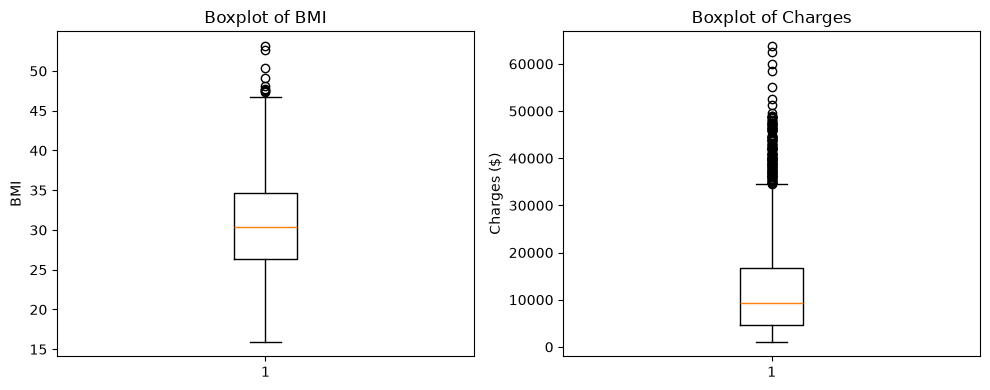

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(data["bmi"].dropna())
plt.title("Boxplot of BMI")
plt.ylabel("BMI")

plt.subplot(1, 2, 2)
plt.boxplot(data["charges"].dropna())
plt.title("Boxplot of Charges")
plt.ylabel("Charges ($)")

plt.tight_layout()
plt.show()

An extreme value is not automatically an error. Outliers should be interpreted in the context of the business problem before deciding whether to remove or transform them.

**Outlier Analysis:**
- **BMI**: Min is 15.96, max is 53.13, mean is 30.66, median is 30.40, with slight skewness (0.28). The boxplot displays a few points above BMI 47. These represent extreme clinical obesity, which is biologically realistic and medically valid.
- **Charges**: Min is $1,121.87, max is $63,770.43, mean is $13,270.42, median is $9,382.03, and skewness is 1.51 (substantially right-skewed). The boxplot displays numerous high values beyond the upper whisker. High charge values are extreme but plausible observations. Their specific clinical cause cannot be determined from the available features, so they should not be removed merely because they are large.

# 8. First Data-Preparation Decisions

Based on the raw data audit performed in Step 1, here is the synthesis of requirements for Step 2:

1. **Duplicates**:
   - The dataset contains 1 duplicate row. In Step 2, we will evaluate removing this duplicate prior to train/test splitting to prevent potential train-test leakage.

2. **Missing Values**:
   - Total missing values is 0 across all features. No imputation (e.g. `SimpleImputer`) will be required.

3. **Categorical Features**:
   - Features `sex`, `smoker`, and `region` are strings. In Step 2, they will be transformed using One-Hot Encoding (`OneHotEncoder`) or binary mapping before feeding into distance-based models.

4. **Numerical Features**:
   - Features `age`, `bmi`, and `children` have different scales. Because K-Nearest Neighbors relies on distance calculations, scaling (such as `StandardScaler` or `RobustScaler`) will be necessary to ensure balanced feature influence.

5. **Outliers**:
   - Extreme values in `bmi` and `charges` reflect genuine healthcare scenarios and patient populations. They will not be dropped blindly; robust scaling or appropriate evaluation metrics (such as MAE alongside RMSE) will be used to assess model robustness against extreme values.

> Note: No modifications, splits, encodings, scalings, or models have been executed in Step 1.

# 9. Handle Duplicates

We found one exact duplicate row during our data quality audit.

The row is an exact duplicate across all available columns. Without a unique customer identifier, we cannot prove whether it represents the same physical person twice.

For this educational project, we will remove the exact duplicate before train/test splitting to avoid the possibility of identical observations appearing across training and test data.

We preserve the original `data` DataFrame and create `data_clean`.


In [20]:
data.duplicated().sum()


np.int64(1)

In [21]:
data_clean = data.drop_duplicates()


In [22]:
print("Length of original data:", len(data))
print("Length of clean data:", len(data_clean))


Length of original data: 1338
Length of clean data: 1337


The duplicate row was successfully removed from `data_clean` (1,338 ? 1,337 rows). The original `data` DataFrame remains completely intact.


# 10. Prepare X and y

For the REGRESSION task:
- Target: `charges`
- Features: All remaining customer attributes (`age`, `sex`, `bmi`, `children`, `smoker`, `region`).

We do not transform `y`.


In [23]:
X = data_clean[
    [
        "age",
        "sex",
        "bmi",
        "children",
        "smoker",
        "region"
    ]
]

y = data_clean["charges"]


In [24]:
X.head()


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [25]:
y.head()


0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1337, 6)
y shape: (1337,)


`X` contains 1,337 rows and 6 features. The target `y` remains continuous unscaled dollar amounts.


# 11. Train / Test Split

We follow the lesson-style `train_test_split` pattern holding out 30% of the data for testing with `random_state=6`.
These values match the insurance regression example from the Performance Metrics lesson.
Stratification is not applied because this is currently a continuous regression task.


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=6
)


In [28]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (935, 6)
X_test shape: (402, 6)
y_train shape: (935,)
y_test shape: (402,)


The dataset is partitioned into 935 training samples (70%) and 402 test samples (30%).


# 12. Encode Categorical Features

The categorical features are `sex`, `smoker`, and `region`.

We follow the lesson-style pattern using `OneHotEncoder`:
- `sparse_output=False`: Returns dense NumPy arrays for direct DataFrame construction.
- `drop="if_binary"`: Drops the first category for binary features (`sex` and `smoker`), keeping a single indicator column (e.g. `sex_male`, `smoker_yes`) to avoid collinearity.
- `handle_unknown="ignore"`: Safely ignores any unforeseen categories during test transformation.

**Core Leakage Rule:**
- `fit()`: Learns categories strictly from the **Training Data** (`X_train`).
- `transform()`: Applies the learned representation to Train and Test separately.
We do NOT fit on `X_test`. We do not use `pandas.get_dummies()` or `OrdinalEncoder`.


In [29]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    drop="if_binary",
    handle_unknown="ignore"
)

encoder.fit(
    X_train[
        ["sex", "smoker", "region"]
    ]
)


,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'if_binary'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_i

In [30]:
encoded_cols = encoder.get_feature_names_out(["sex", "smoker", "region"])
print("Encoded column names:", list(encoded_cols))


Encoded column names: ['sex_male', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [31]:
X_train_cat = pd.DataFrame(
    encoder.transform(X_train[["sex", "smoker", "region"]]),
    columns=encoded_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    encoder.transform(X_test[["sex", "smoker", "region"]]),
    columns=encoded_cols,
    index=X_test.index
)

X_train_cat.head()


,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
399,0.0,0.0,0.0,0.0,1.0,0.0
111,0.0,0.0,0.0,0.0,0.0,1.0
294,1.0,0.0,0.0,0.0,0.0,1.0
408,1.0,0.0,0.0,0.0,1.0,0.0
646,1.0,0.0,0.0,1.0,0.0,0.0


All categorical features are now encoded into numerical indicator columns while strictly preserving sample index alignment.


# 13. Scale Numerical Features

K-Nearest Neighbors is a distance-based algorithm.
The numerical input features are `age`, `bmi`, and `children`.

We use `MinMaxScaler` because:
- These features are strictly non-negative.
- KNN depends directly on geometric distances.
- The lesson identifies MinMax scaling as useful for distance-based methods such as KNN.
- It maps numerical features onto a comparable [0, 1] scale, preventing features with large values (e.g., BMI) from dominating distance metrics over small values (e.g., children).

**Core Leakage Rule:**
- `fit()`: Learns min and max solely from the **Training Data** (`X_train`).
- `transform()`: Scales training data and test data separately.
We do NOT fit on `X_test`. We do NOT scale `charges` (regression target), and we do NOT remove BMI outliers.


In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(
    X_train[
        ["age", "bmi", "children"]
    ]
)


,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](3,)","[64. ,53.13, 5. ]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](3,)","[18. ,15.96, 0. ]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](3,)","[46. ,37.17, 5. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['age','bmi','children']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](3,)","[-0.39,-0.43, 0. ]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,935


In [33]:
num_cols = ["age", "bmi", "children"]

X_train_num = pd.DataFrame(
    scaler.transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

X_train_num.head()


,age,bmi,children
399,0.000000,0.597525,0.0
111,0.804348,0.369653,0.4
294,0.152174,0.291633,0.6
408,0.434783,0.138822,0.6
646,0.456522,0.276029,0.2


Numerical features are scaled to [0, 1] using parameters learned exclusively from training data.


# 14. Build Final Regression Matrices

We concatenate the scaled numerical features and the encoded categorical features into final regression feature matrices: `X_train_prepared` and `X_test_prepared`.


In [34]:
X_train_prepared = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_prepared = pd.concat([X_test_num, X_test_cat], axis=1)

print("X_train_prepared shape:", X_train_prepared.shape)
print("X_test_prepared shape:", X_test_prepared.shape)


X_train_prepared shape: (935, 9)
X_test_prepared shape: (402, 9)


In [35]:
X_train_prepared.head()


,age,bmi,children,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
399,0.000000,0.597525,0.0,0.0,0.0,0.0,0.0,1.0,0.0
111,0.804348,0.369653,0.4,0.0,0.0,0.0,0.0,0.0,1.0
294,0.152174,0.291633,0.6,1.0,0.0,0.0,0.0,0.0,1.0
408,0.434783,0.138822,0.6,1.0,0.0,0.0,0.0,1.0,0.0
646,0.456522,0.276029,0.2,1.0,0.0,0.0,1.0,0.0,0.0


In [36]:
print("Final feature names:", X_train_prepared.columns.tolist())


Final feature names: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [37]:
print("All train columns numeric:", bool((X_train_prepared.dtypes.apply(lambda d: pd.api.types.is_numeric_dtype(d))).all()))
print("All test columns numeric:", bool((X_test_prepared.dtypes.apply(lambda d: pd.api.types.is_numeric_dtype(d))).all()))


All train columns numeric: True
All test columns numeric: True


Both `X_train_prepared` and `X_test_prepared` are 100% numeric matrices containing 9 columns, preserving complete row alignment.


# 15. Verify Scaling

We inspect the minimum and maximum values of the scaled numerical features on both training and test sets.


In [38]:
train_scale_summary = pd.DataFrame({
    "train_min": X_train_num.min(),
    "train_max": X_train_num.max()
})
train_scale_summary


,train_min,train_max
age,0.0,1.0
bmi,0.0,1.0
children,0.0,1.0


In [39]:
test_scale_summary = pd.DataFrame({
    "test_min": X_test_num.min(),
    "test_max": X_test_num.max()
})
test_scale_summary


,test_min,test_max
age,0.000000,1.000000
bmi,0.033226,0.926016
children,0.000000,1.000000


In [40]:
test_outside_0_1 = ((X_test_num < 0) | (X_test_num > 1)).any()
print("Any test features outside [0, 1]:")
print(test_outside_0_1)


Any test features outside [0, 1]:
age         False
bmi         False
children    False
dtype: bool


**Scaling Behavior on Test Data:**

On the training set, `MinMaxScaler` produces values strictly between 0 and 1 because min and max were computed from `X_train`.

On the test set, values are generally near [0, 1], but transformed test values are **not guaranteed** to remain inside [0, 1].
This occurs because `MinMaxScaler` learns min/max only from Training Data. If Test Data contains values outside the Training range (i.e. smaller than training min or larger than training max), the transformed test values can be below 0 or above 1.


# 16. Important Data Leakage Explanation

The ordering of preprocessing operations is fundamental to honest machine learning evaluation:

**Correct Order:**
1. Raw Data Audit
2. Remove exact duplicates (avoids identical observations occurring in both train and test splits)
3. Split Train / Test
4. Fit Encoder and Scaler **only on Training Data**
5. Transform Train and Test data independently

**Anti-Pattern:**
Never fit preprocessing on the full dataset before splitting.
Fitting on the entire dataset allows statistical information from the test data (such as category sets, minimum, maximum, mean, or variance) to influence preprocessing transformations, causing data leakage and overly optimistic metric evaluations.


# 17. Step 2 Verification

We programmatically verify all 14 criteria required for Step 2.


In [41]:
# 1. Original data row count
assert len(data) == 1338, f"Original data has {len(data)} rows, expected 1338"
# 2. Clean data row count
assert len(data_clean) == 1337, f"Clean data has {len(data_clean)} rows, expected 1337"
# 3. Exact duplicates removed from data_clean
assert data_clean.duplicated().sum() == 0, "Clean data still contains duplicates"
# 4. Total missing values remain 0
assert data_clean.isnull().sum().sum() == 0, "Clean data contains missing values"
# 5. y is still raw charges
assert y.name == "charges", f"y target name is {y.name}, expected 'charges'"
# 6. price_range does not exist
assert "price_range" not in data_clean.columns, "'price_range' target must not exist in data_clean"
assert "price_range" not in X_train_prepared.columns, "'price_range' must not exist in features"
# 7. Train/test split used test_size=0.3 and random_state=6
assert len(X_train) == 935 and len(X_test) == 402, f"Unexpected split sizes: {len(X_train)}, {len(X_test)}"
# 8. Encoder was fitted only on training categories
assert set(encoded_cols) == set(encoder.get_feature_names_out(["sex", "smoker", "region"]))
# 9. Scaler was fitted only on training numerical features
assert len(scaler.data_min_) == 3 and len(scaler.data_max_) == 3
# 10. X_train_prepared contains only numeric columns
assert (X_train_prepared.dtypes.apply(lambda d: pd.api.types.is_numeric_dtype(d))).all(), "Non-numeric columns in X_train_prepared"
# 11. X_test_prepared contains only numeric columns
assert (X_test_prepared.dtypes.apply(lambda d: pd.api.types.is_numeric_dtype(d))).all(), "Non-numeric columns in X_test_prepared"
# 12. No NaN values exist
assert X_train_prepared.isnull().sum().sum() == 0, "NaN values in X_train_prepared"
assert X_test_prepared.isnull().sum().sum() == 0, "NaN values in X_test_prepared"
# 13. No rows were removed because of outliers
assert len(X_train_prepared) == 935 and len(X_test_prepared) == 402
# 14. Charges was not scaled
assert y_train.min() == y.loc[X_train.index].min() and y_train.max() == y.loc[X_train.index].max()

print("All Step 2 programmatic verification checks passed successfully!")


All Step 2 programmatic verification checks passed successfully!
